# Download Digital Elevation Model for Study Area

This notebook downloads and saves a DEM from the SRTM for the study area, using the study area boundary created in Notebook 01.

In [8]:
# import libraries

# system compatibility
import os
import pathlib
from pathlib import Path
import sys

# Data Access
import earthaccess

# Data Compatibility
import pandas as pd
import geopandas as gpd
import xarray as xr

# Geographic Data
import rioxarray as rxr

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import holoviews as hv
import hvplot.pandas

In [32]:
# Force Jupyter to reload external modules automatically before executing a cell
# I used Gemini to help me set up the connection to my src files

# force reimporting of src scripts
%load_ext autoreload
%autoreload 2

# Find the parent directory of this notebook (the repo root) and add it to Python's search path
repo_root = str(Path.cwd().parent)
if repo_root not in sys.path:
    sys.path.append(repo_root)

# Now Python can see the src folder
# import just specific functions
from src import dem

# once I'm using environment.yml I can get rid of the above steps

# from src
from src import dem

print('src import complete!')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
src import complete!


In [5]:
# Set paths

# set directories
proj_dir = os.path.join(pathlib.Path.home(),
                        'Documents',
                        'Graduate_School',
                        'EDA_Certificate', 
                        'Summer', 
                        'snow-drought-modeling')
os.makedirs(proj_dir, exist_ok=True)

raw_data_dir = os.path.join(proj_dir, 'data', 'raw')
os.makedirs(raw_data_dir, exist_ok=True)

cleaned_data_dir = os.path.join(proj_dir, 'data', 'cleaned')
os.makedirs(raw_data_dir, exist_ok=True)

## Step 2: Load Missouri Headwaters boundary

In [6]:
# set paths
mhw_path = Path(raw_data_dir, 'boundaries', 'mhw_gdf.parquet')
mhw_train_path = Path(cleaned_data_dir, 'boundaries', 'mhw_buff_clip_gdf.parquet')
prism_rast_path = Path(raw_data_dir, 'prism', 'full_rasters')

In [9]:
# load the mhw boundary gdf
mhw_gdf = gpd.read_parquet(mhw_path)

# and the buffered gdf
mhw_train_gdf = gpd.read_parquet(mhw_train_path)

## Step 3: Login to Earth Access Database and search for SRTM data

You will need to enter valid credentials to download the SRTM DEM.

In [10]:
# login to earthaccess

earthaccess.login()

In [11]:
# Search for SRTM data

datasets = earthaccess.search_datasets(keyword = 'SRTM DEM')
for dataset in datasets:
    print(dataset['umm']['ShortName'], dataset['umm']['EntryTitle'])

ICRAF_AfSIS_AfrHySRTM Africa Soil Information Service (AfSIS): Hydrologically Corrected/Adjusted SRTM DEM (AfrHySRTM)
NASADEM_SHHP NASADEM SRTM-only Height and Height Precision Mosaic Global 1 arc second V001
NASADEM_SIM NASADEM SRTM Image Mosaic Global 1 arc second V001
NASADEM_SSP NASADEM SRTM Subswath Global 1 arc second V001
USGS_OFR_2004_1322 Digital Shaded-Relief Map of Venezuela
C_Pools_Fluxes_CONUS_1837 CMS: Terrestrial Carbon Stocks, Emissions, and Fluxes for Conterminous US, 2001-2016
SRTMGL1 NASA Shuttle Radar Topography Mission Global 1 arc second V003
NASADEM_HGT NASADEM Merged DEM Global 1 arc second V001
AST14DEM ASTER Digital Elevation Model V004
GEDI02_B GEDI L2B Canopy Cover and Vertical Profile Metrics Data Global Footprint Level V002
SRTMGL3 NASA Shuttle Radar Topography Mission Global 3 arc second V003
GEDI01_B GEDI L1B Geolocated Waveform Data Global Footprint Level V002
SRTMGL1N NASA Shuttle Radar Topography Mission Global 1 arc second number V003
NASADEM_SC NASA

## Step 4: Download SRTM tiles

In [12]:
# set download dir and pattern

# directory
topo_dir = Path(raw_data_dir, 'topo')
os.makedirs(topo_dir, exist_ok=True)

# SRTM pattern
srtm_pattern = os.path.join(topo_dir, '*.hgt.zip')

In [33]:
# Download SRTM tiles

srtm_files = dem.download_srtm_tiles(mhw_train_gdf, topo_dir, srtm_pattern)

SRTM Files have already been downloaded!


## Step 5: Merge tiles

In [34]:
# Make the DA of merged tiles
mhw_elevation_da = dem.merge_srtm_tiles(srtm_pattern, mhw_train_gdf)

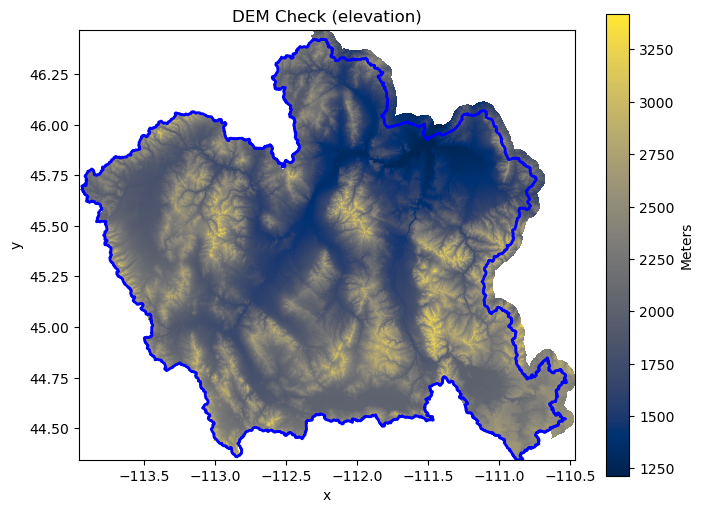

In [36]:
# visualize to check data

# set up plot
fig, ax = plt.subplots(figsize=(8,6))

# plot first timestep of prism data
mhw_elevation_da.plot(
    ax=ax, 
    cmap='cividis',
    cbar_kwargs = {'label': 'Meters'})

# overlay MHW boundary
mhw_gdf.plot(ax=ax, facecolor = 'none', edgecolor = 'blue', linewidth= 2)
plt.title('DEM Check (elevation)')
plt.show()


## Step 6: Calculate Slope and Aspect; save all three rasters

In [ ]:
# calculate slope
mhw_slope_da = dem.calculate_slope(mhw_elevation_da, mhw_train_gdf)

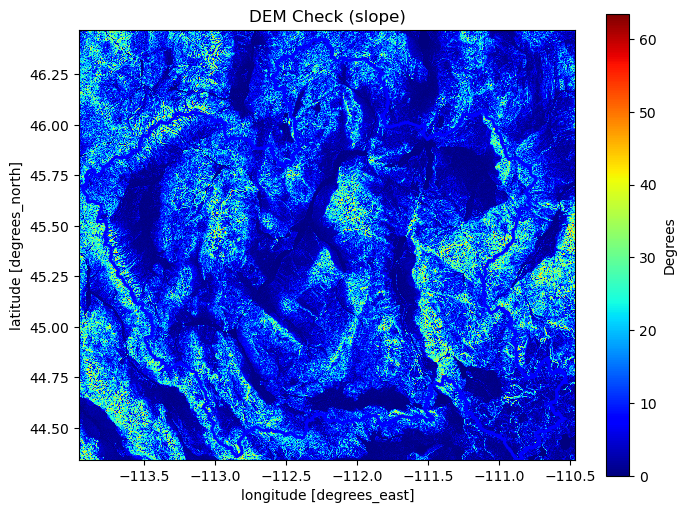

In [42]:
# visualize to check data

# set up plot
fig, ax = plt.subplots(figsize=(8,6))

# plot first timestep of prism data
mhw_slope_da.plot(
    ax=ax, 
    cmap='jet',
    cbar_kwargs = {'label': 'Degrees'})

# overlay MHW boundary
mhw_gdf.plot(ax=ax, facecolor = 'none', edgecolor = 'blue', linewidth= 2)
plt.title('DEM Check (slope)')
plt.show()


In [ ]:
# calculate aspect
mhw_aspect_da = dem.calculate_aspect(mhw_elevation_da, mhw_train_gdf)

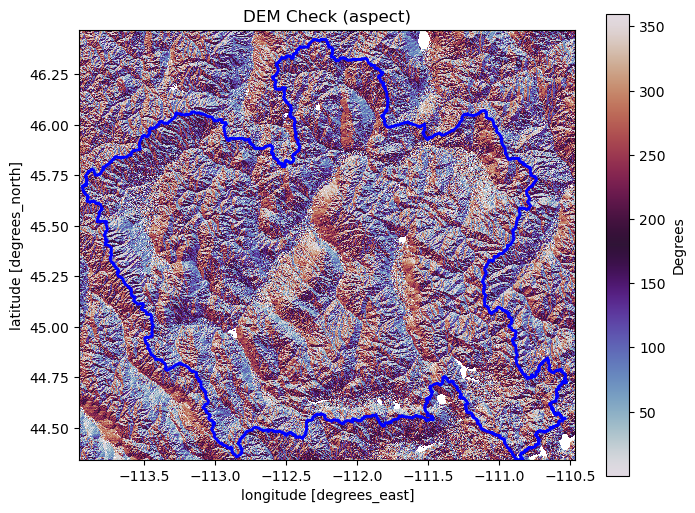

In [43]:
# visualize to check data

# set up plot
fig, ax = plt.subplots(figsize=(8,6))

# plot first timestep of prism data
mhw_aspect_da.plot(
    ax=ax, 
    cmap='twilight',
    cbar_kwargs = {'label': 'Degrees'})

# overlay MHW boundary
mhw_gdf.plot(ax=ax, facecolor = 'none', edgecolor = 'blue', linewidth= 2)
plt.title('DEM Check (aspect)')
plt.show()


In [24]:
# save to file 

# set a subfolder to hold master rasters
topo_master_dir = Path(topo_dir, 'masters')
os.makedirs(topo_master_dir, exist_ok= True)

# set paths
mhw_elevation_path = Path(topo_master_dir, 'mhw_elevation_30m.tif')
mhw_slope_path = Path(topo_master_dir, 'mhw_slope_30m.tif')
mhw_aspect_path = Path(topo_master_dir, 'mhw_aspect_30m.tif')

# clear conflicting NoData values in DAs
for da in [mhw_elevation_da, mhw_slope_da, mhw_aspect_da]:
    if '_FillValue' in da.attrs:
        del da.attrs['_FillValue']

# save
mhw_elevation_da.rio.to_raster(mhw_elevation_path)
mhw_slope_da.rio.to_raster(mhw_slope_path)
mhw_aspect_da.rio.to_raster(mhw_aspect_path)

## Step 7: Upscale to 4km resolution to match PRISM data